This notebook demonstrates the effects of progressively adding collision physics to dust evolution in a protoplanetary disk, following the setup of [Windmark+2012](https://ui.adsabs.harvard.edu/abs/2012A%26A...540A..73W/abstract). Each section compares results **without** vs. **with** a Maxwell-Boltzmann velocity distribution (VD). The physics modules are:

1. **CF** -- Coagulation + Fragmentation
2. **CBF** -- Coagulation + Bouncing + Fragmentation
3. **CBF+MT** -- adds Mass Transfer (accounting for the effects of cratering and modulated mass transfer in addition to destructive fragmentation)
4. **CBF+MT+fmod** -- adds $f_{\rm mod}$, a modulation factor to limit the artificial growth of mass bins with unrealistic low number densities.

All of these pictures were used in the Appendix of [Li, Chen & Lin (2022)](https://ui.adsabs.harvard.edu/abs/2022MNRAS.510.5246L).

In [1]:
# standard imports
import numpy as np
np.set_printoptions(edgeitems=5, linewidth=175, precision=5)
import matplotlib as mpl
import matplotlib.pyplot as plt
import pyridoxine.plt as rxplt
import astropy.constants as c
import astropy.units as u

import mpmath as mp
import torch
torch.set_printoptions(edgeitems=5, linewidth=175, precision=5)

from rubble import Rubble, RubbleData, RubbleTorch
dt_1d = 86400; dt_1yr = dt_1d * 365.25  # seconds per day / per year

In [2]:
# calculate the gas scale height H used in Windmark+2012: H = c_s / Omega at 1 AU, T=280 K
H_W12 = np.sqrt(c.k_B * 280*u.K / (2.3*c.m_p)).to(u.cm/u.s) / np.sqrt(c.G * c.M_sun / u.au**3).to(1/u.s)

# 1. Coagulation + Fragmentation (CF), w/ and w/o Velocity Distribution

The simplest case: particles either stick or fragment upon collision. Left panel: deterministic threshold velocity. Right panel: Maxwell-Boltzmann velocity distribution smooths the fragmentation barrier.

In [3]:
# CF without velocity distribution: delta-dist at 1e-4 cm, Windmark+2012 disk parameters
# Sigma_g=1700 g/cm^2, T=280 K, alpha=1e-4, u_f=100 cm/s (=1 m/s), rho_m=1.0 g/cm^3
rt = RubbleTorch(151, 1e-4, 1e2, 3.5, 17, rho_m = 1.0,
                delta_dist=1e-4, coag2nearest=True,
                Sigma_g = 1700, H = H_W12.value, T = 280, alpha = 1e-4, u_f = 100,
                run_name = "demo2_data/CF_noVD_C2N")

rt.vel_dist_flag = False   # no Maxwell-Boltzmann velocity distribution
rt.bouncing_flag = False   # no bouncing
rt.mass_transfer_flag = False  # no mass transfer
rt.f_mod_flag = True       # enable fragmentation modifier (mass-ratio dependent)

Selected torch device:  cuda ; default_dtype:  torch.float64


In [4]:
# evolve for 50000 yr with dt=2.5 yr
rt.run(50000, 2.5, 2.5)

In [5]:
# free GPU memory before the next run
del rt
torch.cuda.empty_cache()

In [6]:
# CF with velocity distribution: same parameters, but vel_dist_flag defaults to True
rt = RubbleTorch(151, 1e-4, 1e2, 3.5, 17, rho_m = 1.0,
           delta_dist=1e-4, coag2nearest=True, u_f = 100,
           Sigma_g = 1700, H = H_W12.value, T = 280, alpha = 1e-4,           
           run_name = "demo2_data/CF_VD_C2N")

rt.bouncing_flag = False
rt.mass_transfer_flag = False
rt.f_mod_flag = True

Selected torch device:  cuda ; default_dtype:  torch.float64


In [7]:
rt.run(50000, 2.5, 2.5)

<IPython.core.display.Javascript object>


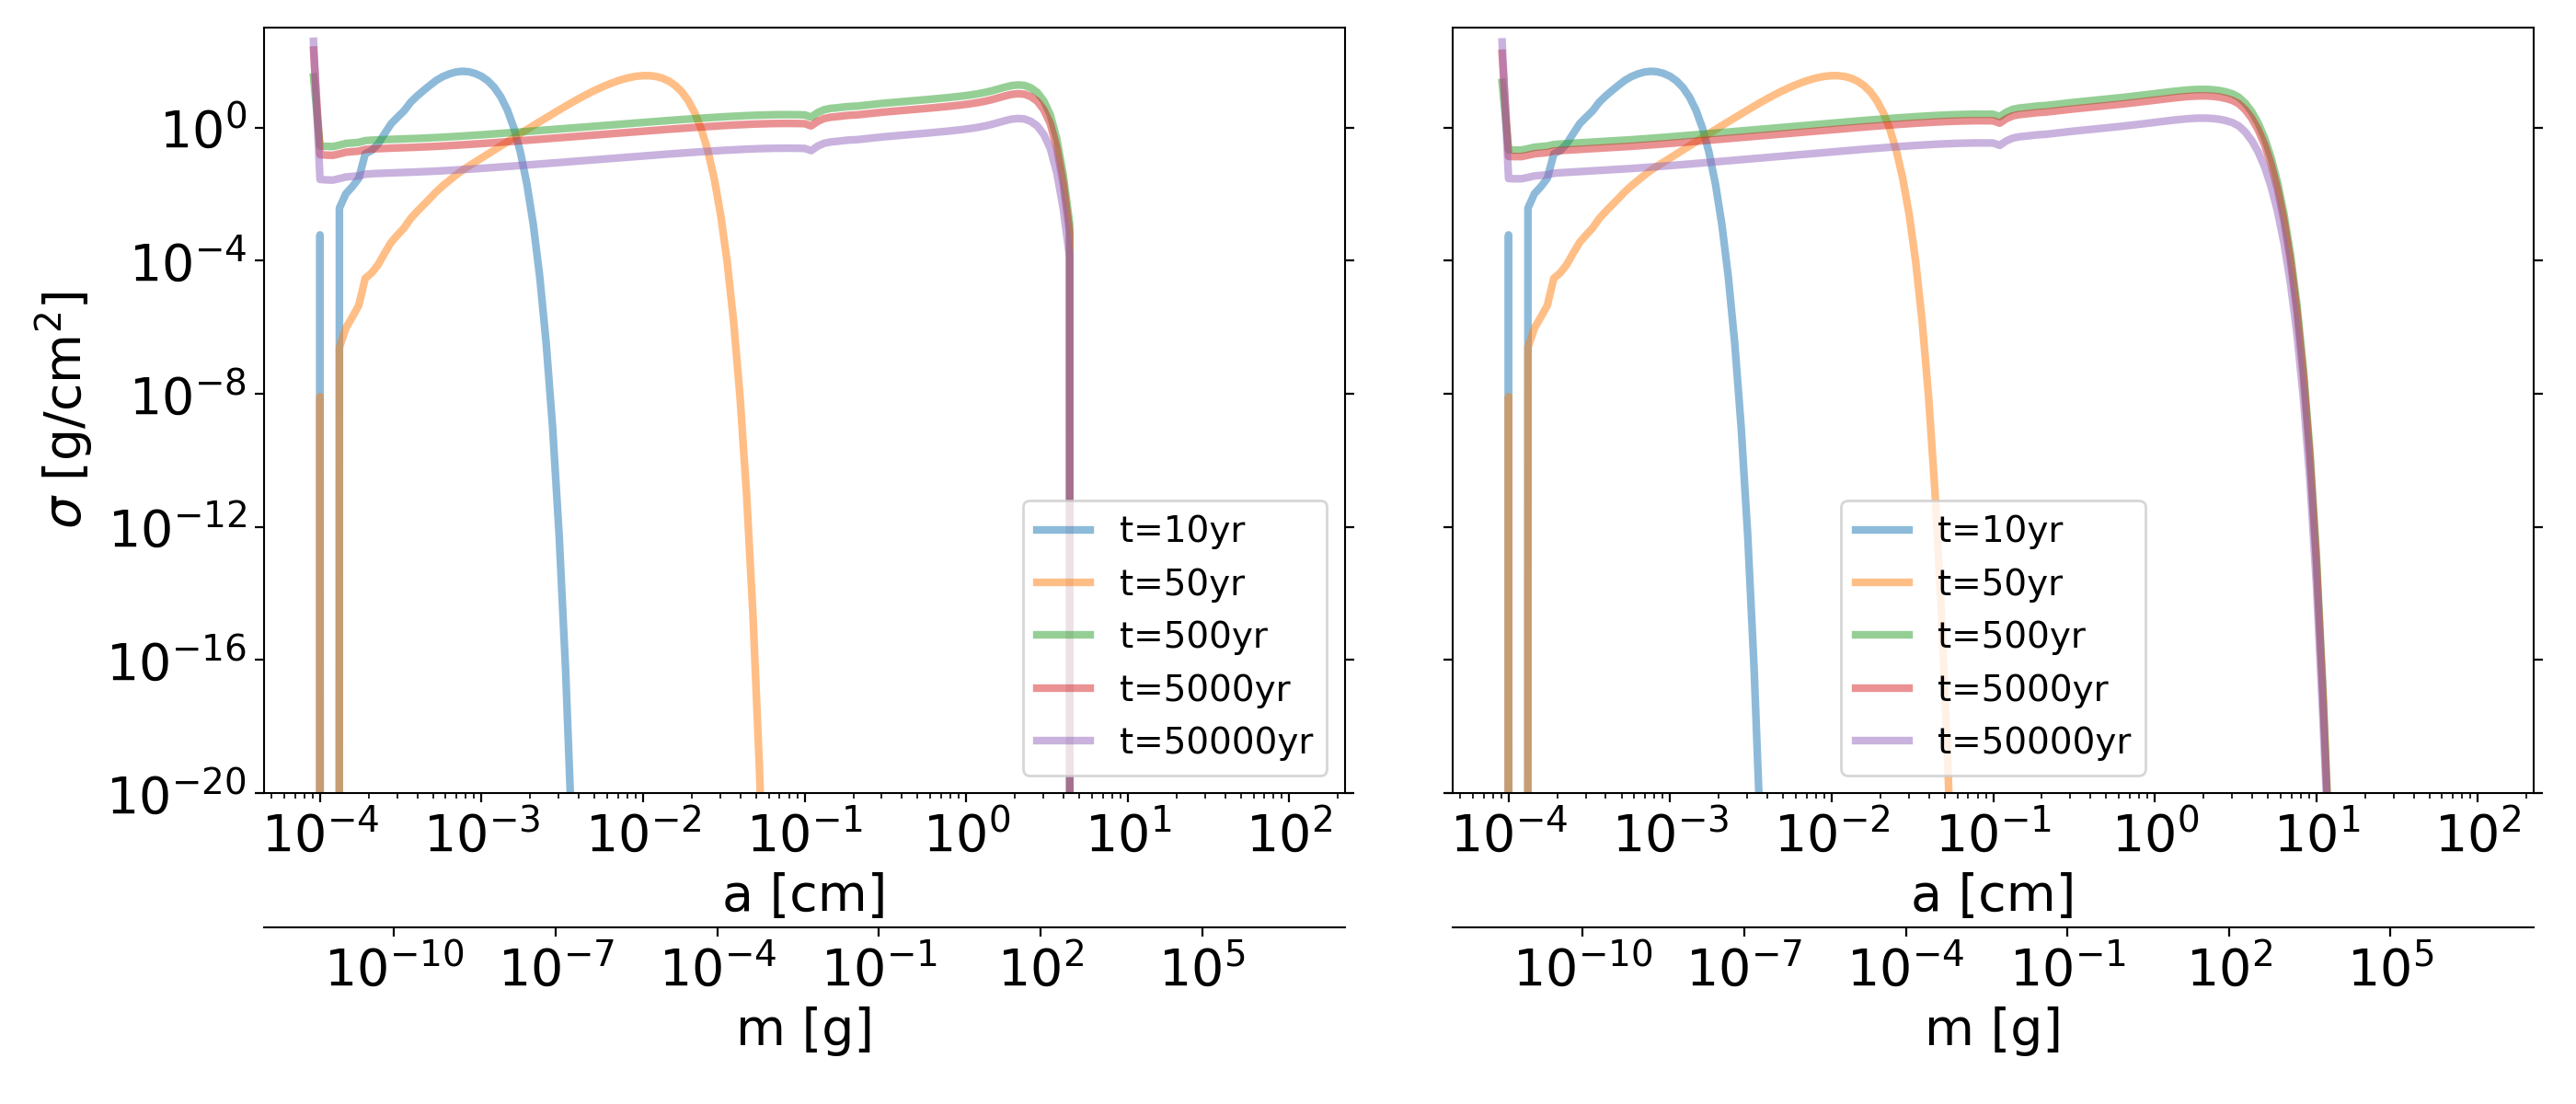

In [9]:
# compare CF without VD (left) vs. with VD (right)
rd = [RubbleData("demo2_data/CF_noVD_C2N.dat"), RubbleData("demo2_data/CF_VD_C2N.dat")]
rxplt.plt_params('l'); fig, ax = plt.subplots(1, 2, figsize=(14, 6), sharey='row')
rd[0].plot_snapshots([10, 50, 500, 5000, 50000], ax = ax[0])
rd[1].plot_snapshots([10, 50, 500, 5000, 50000], ax = ax[1])
ax[0].set(ylim=[1e-20, 1e3]); ax[1].set(ylabel=None)
fig.tight_layout(); fig.subplots_adjust(wspace=0.1)

# 2. Coagulation + Bouncing + Fragmentation (CBF), w/ and w/o VD

Adding a bouncing barrier: particles below the fragmentation velocity but above the bouncing threshold bounce instead of sticking, creating a "bouncing barrier" that limits growth.

In [10]:
# CBF without velocity distribution: bouncing is now enabled (default)
rt = RubbleTorch(151, 1e-4, 1e2, 3.5, 17, rho_m = 1.0,
                delta_dist=1e-4, coag2nearest=True, 
                Sigma_g = 1700, H = H_W12.value, T = 280, alpha = 1e-4, u_f = 100,
                run_name = "demo2_data/CBF_noVD_C2N")

rt.vel_dist_flag = False
rt.mass_transfer_flag = False
rt.f_mod_flag = True

Selected torch device:  cuda ; default_dtype:  torch.float64


In [11]:
rt.run(50000, 2.5, 2.5)

In [12]:
del rt
torch.cuda.empty_cache()

In [13]:
# CBF with velocity distribution
rt = RubbleTorch(151, 1e-4, 1e2, 3.5, 17, rho_m = 1.0,
                 delta_dist=1e-4, coag2nearest=True,
                 Sigma_g = 1700, H = H_W12.value, T = 280, alpha = 1e-4, u_f = 100,
                 run_name = "demo2_data/CBF_VD_C2N")

rt.mass_transfer_flag = False
rt.f_mod_flag = True

Selected torch device:  cuda ; default_dtype:  torch.float64


In [14]:
rt.run(50000, 2.5, 2.5)

<IPython.core.display.Javascript object>


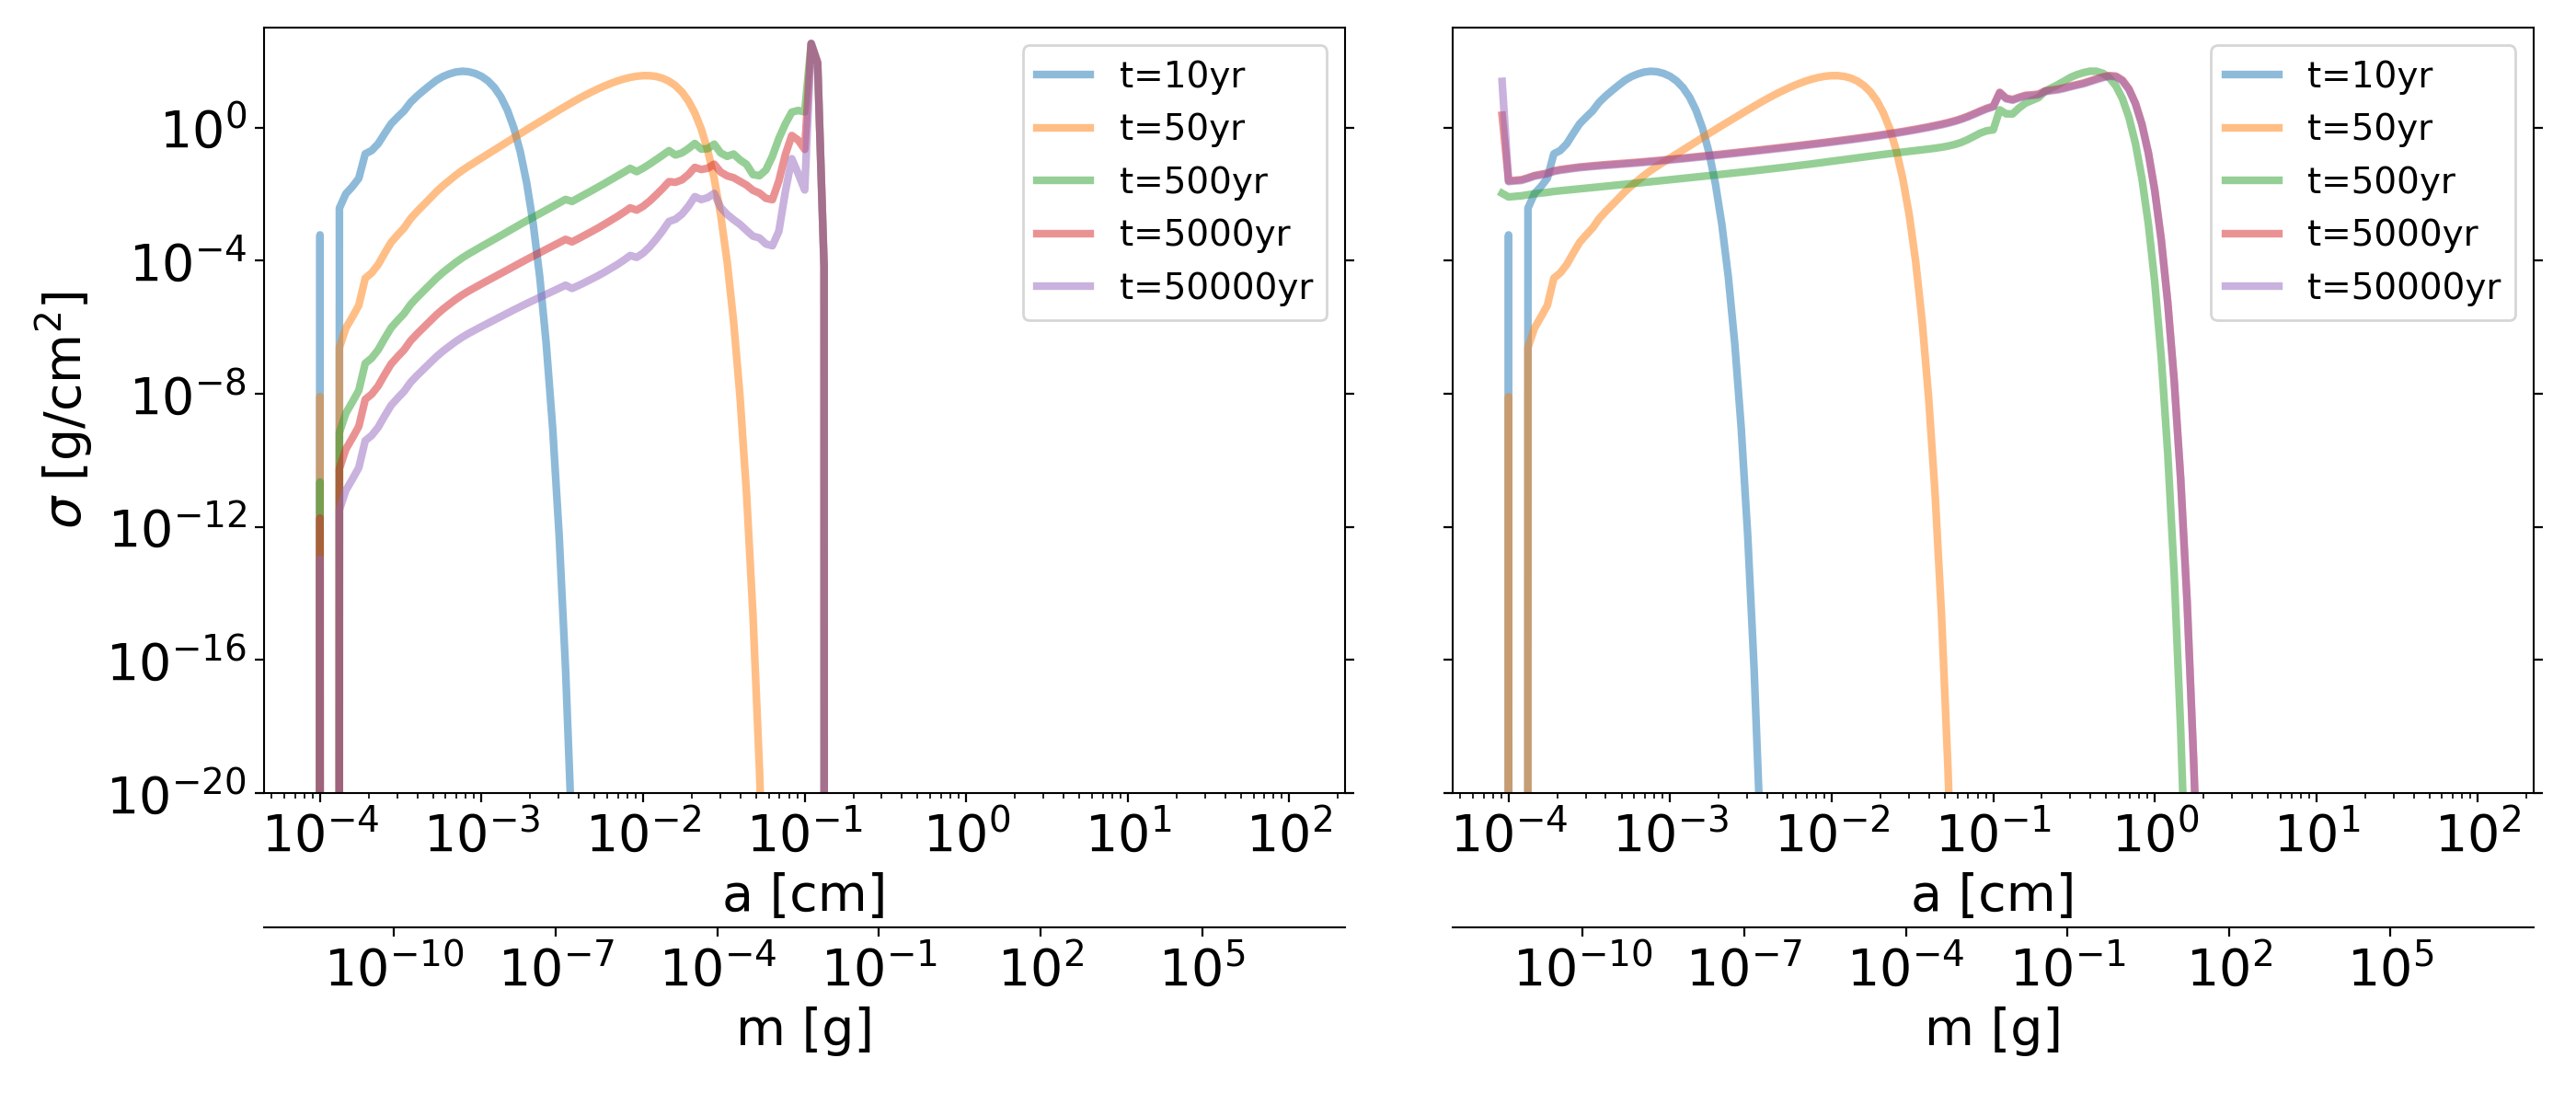

In [16]:
# compare CBF without VD (left) vs. with VD (right)
rd = [RubbleData("demo2_data/CBF_noVD_C2N.dat"), RubbleData("demo2_data/CBF_VD_C2N.dat")]
rxplt.plt_params('l'); fig, ax = plt.subplots(1, 2, figsize=(14, 6), sharey='row')
rd[0].plot_snapshots([10, 50, 500, 5000, 50000], ax = ax[0])
rd[1].plot_snapshots([10, 50, 500, 5000, 50000], ax = ax[1])
ax[0].set(ylim=[1e-20, 1e3]); ax[1].set(ylabel=None)
fig.tight_layout(); fig.subplots_adjust(wspace=0.1)

# 3. CBF + Mass Transfer (MT), w/ and w/o VD

`MT` here means only particles of similar mass will fully fragment; when `m_tg/m_pj > 10`, small projectiles would erode a fraction of mass from large targets, and both fragment; when `m_tg/m_pj > 50`, small projectiles actually deposit a small fraction of mass onto large targets, the remaining fragments.

In [18]:
# CBF+MT without velocity distribution
rt = RubbleTorch(151, 1e-4, 1e2, 3.5, 17, rho_m = 1.0,
                 delta_dist=1e-4, coag2nearest=True,
                 Sigma_g = 1700, H = H_W12.value, T = 280, alpha = 1e-4, u_f = 100,
                 run_name = "demo2_data/CBF_MT_noVD_C2N")

rt.vel_dist_flag = False
rt.f_mod_flag = True

Selected torch device:  cuda ; default_dtype:  torch.float64


In [19]:
rt.run(50000, 2.5, 2.5)

In [20]:
del rt
torch.cuda.empty_cache()

In [21]:
# CBF+MT with VD but without f_mod -- wider mass range to capture mass transfer breakthrough
rt = RubbleTorch(176, 1e-4, 1e3, 3.5, 17, rho_m = 1.0,
                 delta_dist=1e-4, coag2nearest=True,
                 Sigma_g = 1700, H = H_W12.value, T = 280, alpha = 1e-4, u_f = 100,
                 run_name = "demo2_data/CBF_MT_VD_C2N_nofmod")

rt.f_mod_flag = False

Selected torch device:  cuda ; default_dtype:  torch.float64


In [22]:
rt.run(50000, 2.5, 2.5)

<IPython.core.display.Javascript object>


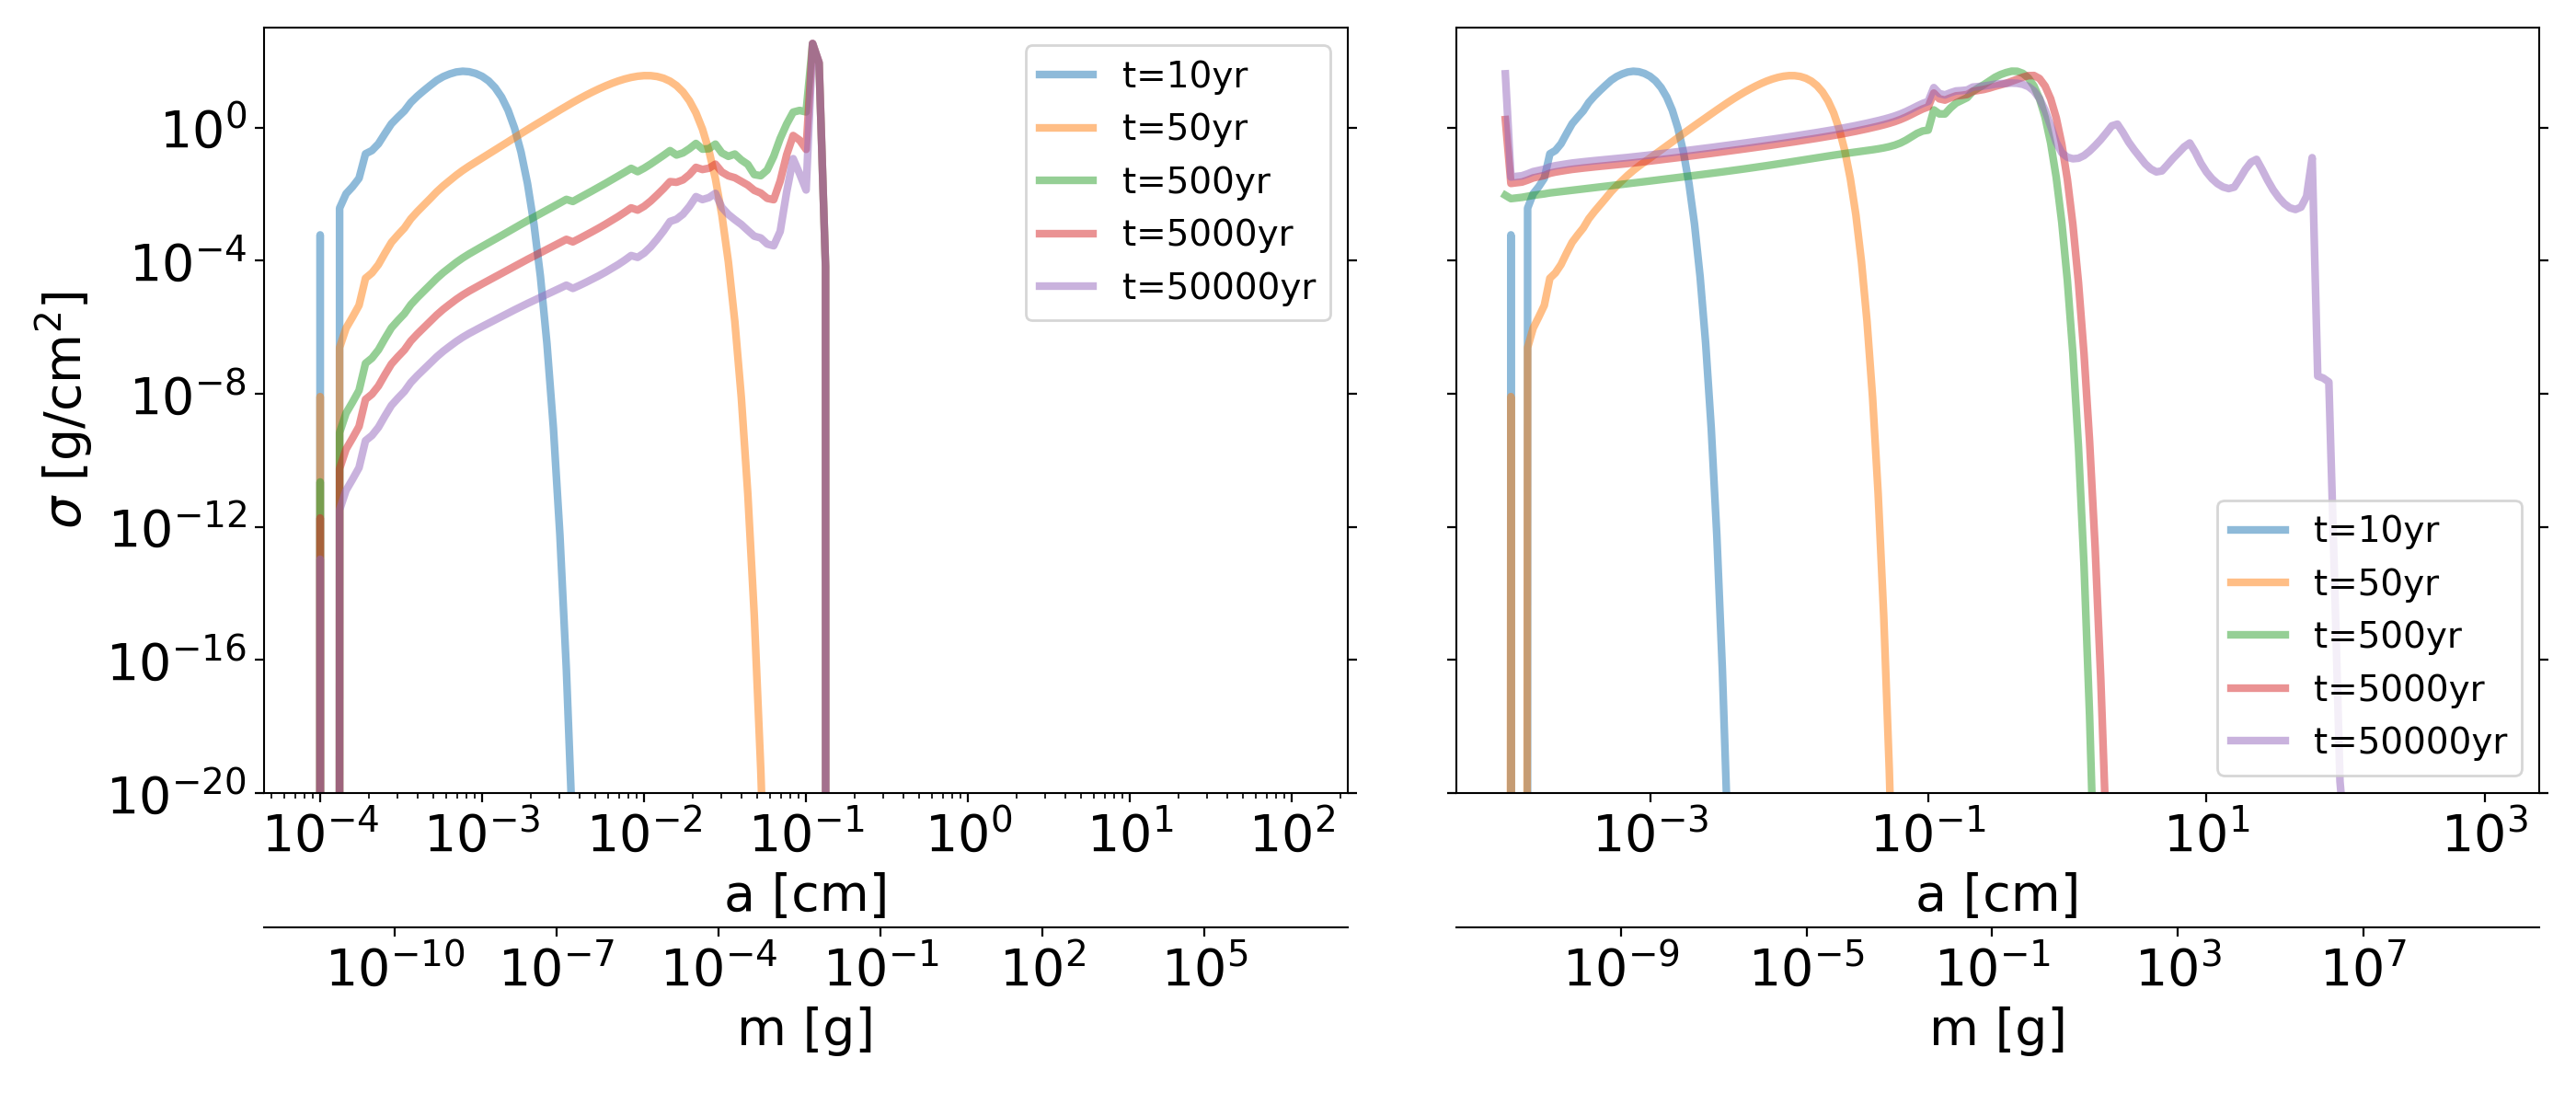

In [23]:
# compare CBF+MT: no VD w/ fmod (left) vs. VD w/o fmod (right)
rd = [RubbleData("demo2_data/CBF_MT_noVD_C2N.dat"), RubbleData("demo2_data/CBF_MT_VD_C2N_nofmod.dat")]
rxplt.plt_params('l'); fig, ax = plt.subplots(1, 2, figsize=(14, 6), sharey='row')
rd[0].plot_snapshots([10, 50, 500, 5000, 50000], ax = ax[0])
rd[1].plot_snapshots([10, 50, 500, 5000, 50000], ax = ax[1])
ax[0].set(ylim=[1e-20, 1e3]); ax[1].set(ylabel=None)
fig.tight_layout(); fig.subplots_adjust(wspace=0.1)

# 4. CBF + MT + Modulation Factor ($f_{\rm mod}$), w/ and w/o VD

The modulation factor limits the artificial growth of mass bins with unrealistic low number densities (e.g., `N < 1`). It basically make such mass bins inactive. Left panel: VD + MT without $f_{\rm mod}$ (same as right panel above). Right panel: the full model with $f_{\rm mod}$ enabled.

In [24]:
# full model: CBF + MT + VD + fmod
rt = RubbleTorch(176, 1e-4, 1e3, 3.5, 17, rho_m = 1.0,
                 delta_dist=1e-4, coag2nearest=True,
                 Sigma_g = 1700, H = H_W12.value, T = 280, alpha = 1e-4, u_f = 100,
                 run_name = "demo2_data/CBF_MT_VD_C2N")
rt.f_mod_flag = True

Selected torch device:  cuda ; default_dtype:  torch.float64


In [25]:
rt.run(50000, 2.5, 2.5)

<IPython.core.display.Javascript object>


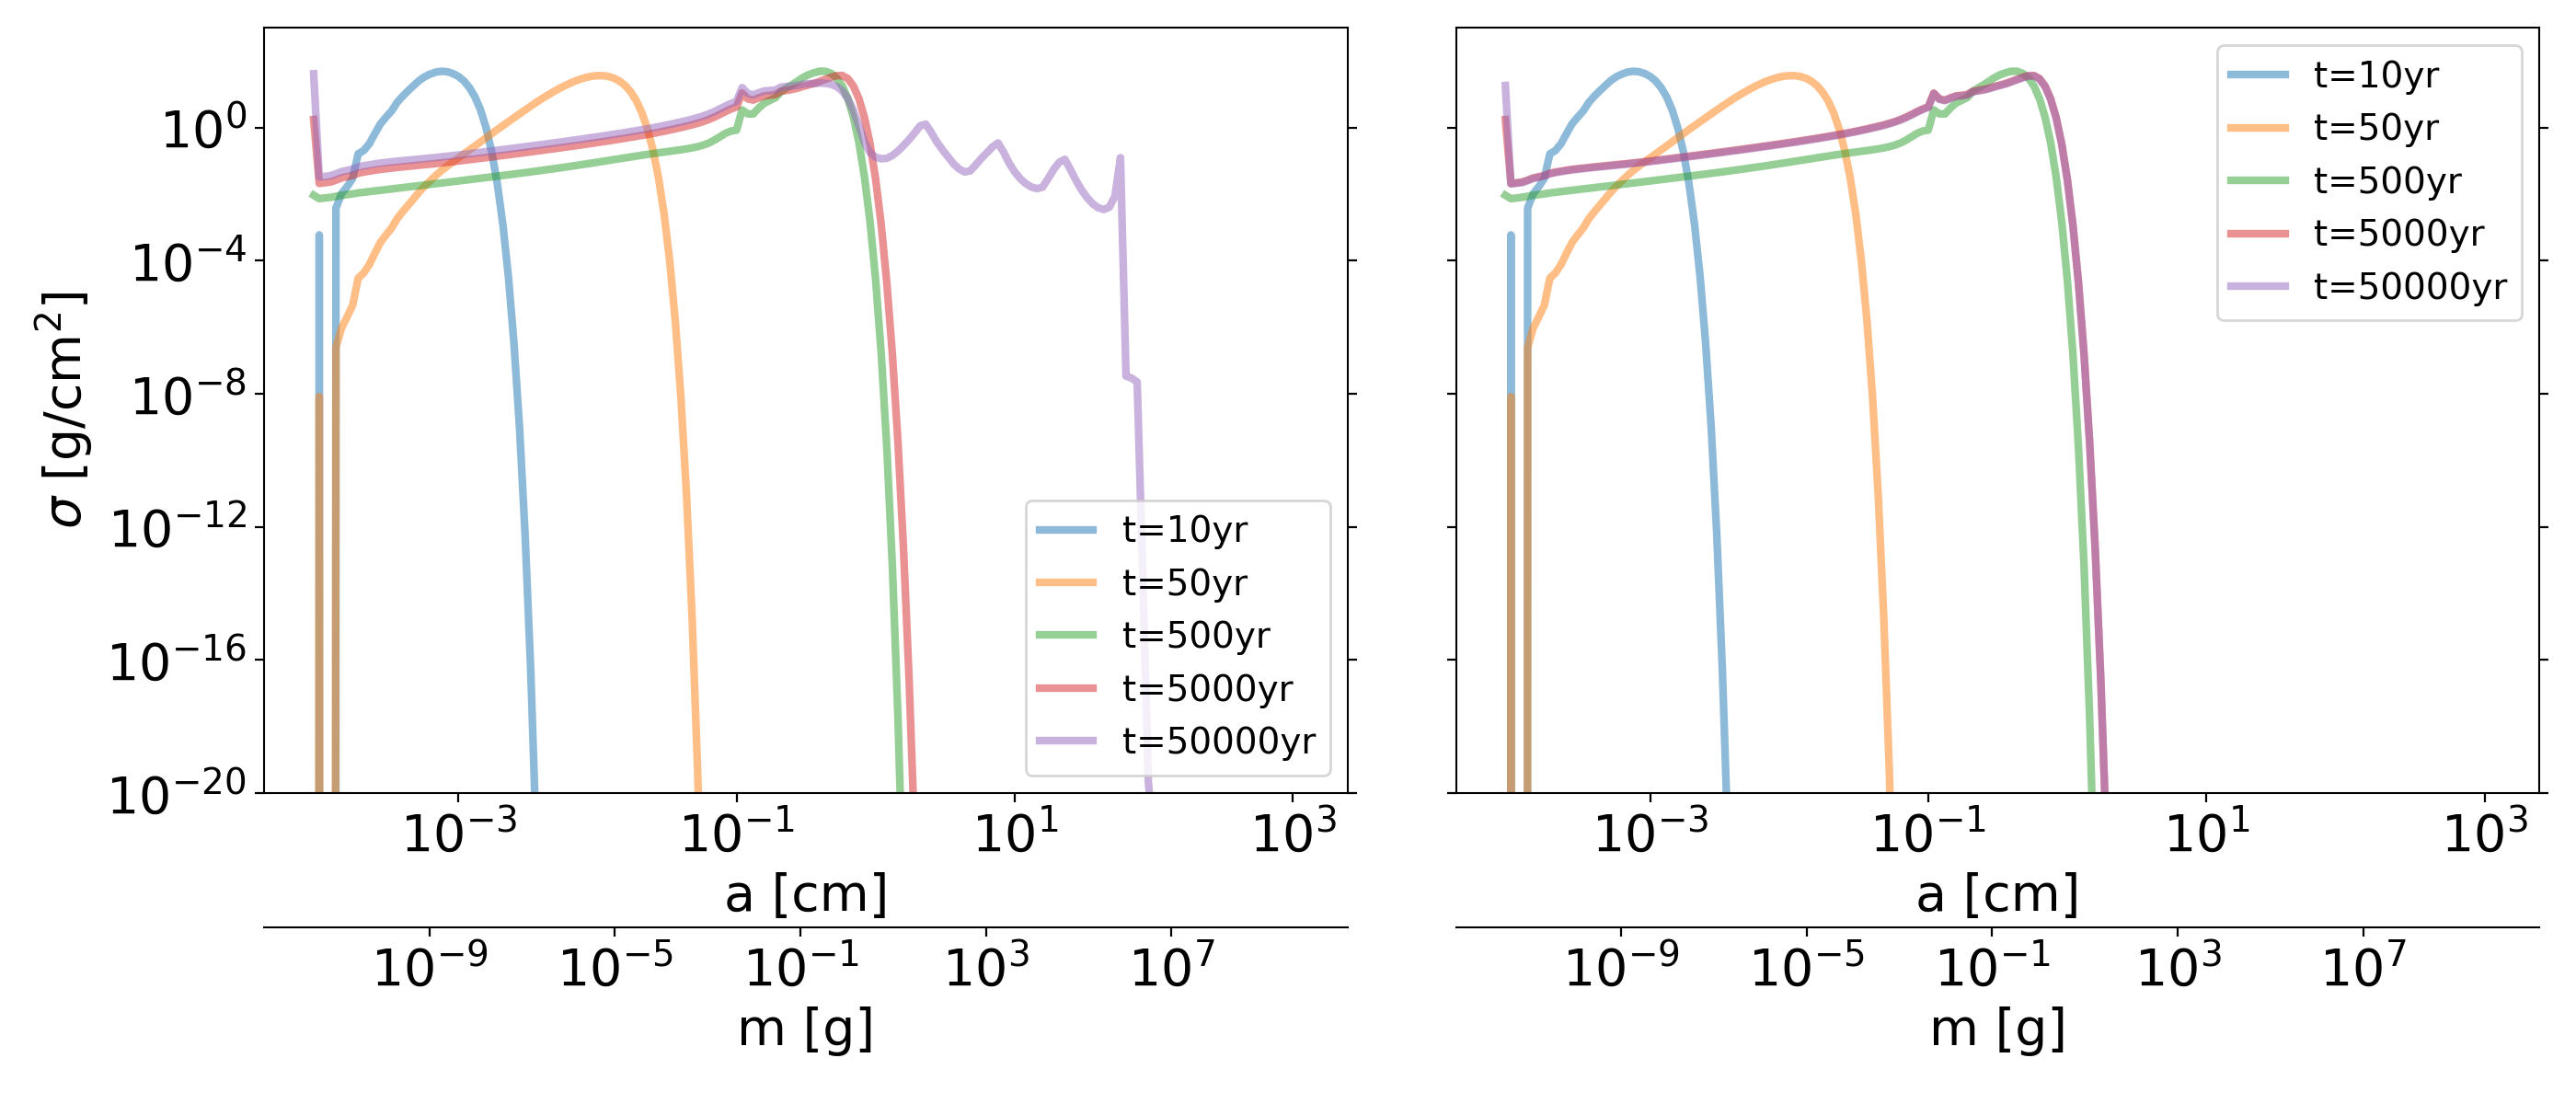

In [26]:
# compare: VD+MT w/o fmod (left) vs. VD+MT w/ fmod (right) -- the full model
rd = [RubbleData("demo2_data/CBF_MT_VD_C2N_nofmod.dat"), RubbleData("demo2_data/CBF_MT_VD_C2N.dat")]
rxplt.plt_params('l'); fig, ax = plt.subplots(1, 2, figsize=(14, 6), sharey='row')
rd[0].plot_snapshots([10, 50, 500, 5000, 50000], ax = ax[0])
rd[1].plot_snapshots([10, 50, 500, 5000, 50000], ax = ax[1])
ax[0].set(ylim=[1e-20, 1e3]); ax[1].set(ylabel=None)
fig.tight_layout(); fig.subplots_adjust(wspace=0.1)